In [161]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Financial Analysis: Bitcoin Price Correlation with Social Media Sentiment

## Introduction

Cryptocurrencies, led by Bitcoin, have introduced a new era of digital finance characterized by extreme volatility and 24/7 global trading. Unlike traditional assets, which are often valued based on quarterly earnings or dividends, Bitcoin is heavily driven by market psychology and retail investor sentiment.

With the rise of social media platforms like Twitter and Reddit, information spreads instantly, creating feedback loops. This project aims to quantify the relationship between these social signals and market movements using data science.

## Hyphotheses

* Null Hypothesis ($H_0$): There is no significant correlation between social media sentiment volume and Bitcoin price changes.
 
* Alternative Hypothesis ($H_1$): There is a positive correlation between social media activity/sentiment and Bitcoin price volatility.

### Data Loading and Initial Inspection

In this step, I import the primary datasets: Bitcoin historical price data and Twitter activity logs. The objective is to merge these sources to analyze potential correlations between social media sentiment and market price movements.

In [129]:
bitcoin_df = pd.read_csv('bitcoin.csv')
bitcoin_df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [40]:
tweets_df = pd.read_csv('bitcoin_tweets.csv', nrows=100000)
tweets_df.head()

C:\Users\ivona\AppData\Local\Temp\ipykernel_18512\1260225277.py:1: DtypeWarning: Columns (5,6,7,12) have mixed types. Specify dtype option on import or set low_memory=False.
  tweets_df = pd.read_csv('bitcoin_tweets.csv', nrows=100000)


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,DeSota Wilson,"Atlanta, GA","Biz Consultant, real estate, fintech, startups...",2009-04-26 20:05:09,8534.0,7605,4838,False,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...,['bitcoin'],Twitter Web App,False
1,CryptoND,NaN,😎 BITCOINLIVE is a Dutch platform aimed at inf...,2019-10-17 20:12:10,6769.0,1532,25483,False,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""...","['Thursday', 'Btc', 'wallet', 'security']",Twitter for Android,False
2,Tdlmatias,"London, England","IM Academy : The best #forex, #SelfEducation, ...",2014-11-10 10:50:37,128.0,332,924,False,2021-02-10 23:54:48,"Guys evening, I have read this article about B...",NaN,Twitter Web App,False
3,Crypto is the future,NaN,I will post a lot of buying signals for BTC tr...,2019-09-28 16:48:12,625.0,129,14,False,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...,"['Bitcoin', 'FX', 'BTC', 'crypto']",dlvr.it,False
4,Alex Kirchmaier 🇦🇹🇸🇪 #FactsSuperspreader,Europa,Co-founder @RENJERJerky | Forbes 30Under30 | I...,2016-02-03 13:15:55,1249.0,1472,10482,False,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...,['BTC'],Twitter Web App,False


In [36]:
tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_name         99998 non-null   object 
 1   user_location     53373 non-null   object 
 2   user_description  93298 non-null   object 
 3   user_created      100000 non-null  object 
 4   user_followers    100000 non-null  float64
 5   user_friends      100000 non-null  object 
 6   user_favourites   100000 non-null  object 
 7   user_verified     100000 non-null  object 
 8   date              100000 non-null  object 
 9   text              100000 non-null  object 
 10  hashtags          83253 non-null   object 
 11  source            96685 non-null   object 
 12  is_retweet        99999 non-null   object 
dtypes: float64(1), object(12)
memory usage: 9.9+ MB


In [96]:
bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7525130 entries, 0 to 7525129
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 344.5 MB


### Data Cleaning and Date Standardization

I selected the 'Timestamp' and 'Close' price from the Bitcoin dataset and 'date' from the Twitter dataset. The 'Close' price is the most reliable metric for daily market value, while the date columns are essential as the "key" to link both datasets. By focusing only on these categories, I remove noise and keep the analysis focused on the direct relationship between price and social noise.

In [132]:
bitcoin_df = bitcoin_df[['Timestamp', 'Close']]

In [66]:
tweets_df = tweets_df[['date', 'text', 'user_followers']]

Raw data often stores dates as plain text or Unix timestamps, which computers cannot automatically compare. Converting these to a standardized 'datetime' format is crucial.

In [130]:
bitcoin_df['Timestamp'] = pd.to_datetime(bitcoin_df['Timestamp'], unit='s', errors='coerce')
tweets_df['date'] = pd.to_datetime(tweets_df['date'], errors='coerce')

In [120]:
tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99999 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            99999 non-null  datetime64[ns]
 1   text            99999 non-null  object        
 2   user_followers  99999 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 3.1+ MB


In [133]:
bitcoin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7525130 entries, 0 to 7525129
Data columns (total 2 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Timestamp  datetime64[ns]
 1   Close      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 114.8 MB


In [134]:
bitcoin_df['Timestamp'] = bitcoin_df['Timestamp'].dt.normalize()
tweets_df['date'] = tweets_df['date'].dt.normalize()

In [135]:
bitcoin_df = bitcoin_df.dropna(subset=['Timestamp'])
tweets_df = tweets_df.dropna(subset=['date'])

### Data Aggregation and Merging

The Bitcoin data contained multiple price points per day, whereas the Twitter data was provided as a daily total. I aggregated the price to a daily mean to ensure a match. This prevents data duplication and provides a cleaner, more accurate overview of the daily trends.

In [136]:
tweets_daily = tweets_df.groupby('date').size().reset_index(name='Tweet_Volume')

In [137]:
combined_df = pd.merge(bitcoin_df, tweets_daily, left_on='Timestamp', right_on='date', how='inner')

In [153]:
combined_df.columns = ['Date','BTC Price', 'Tweet Date', 'Tweet Volume']
combined_df.index = range(1, len(combined_df) + 1)

In [156]:
final_daily_df = combined_df.groupby('Date').agg({
    'BTC Price': 'mean',
    'Tweet Volume': 'first'
}).reset_index()

final_daily_df['BTC Price'] = final_daily_df['BTC Price'].round(2)
final_daily_df.index = range(1, len(final_daily_df) + 1)

In [157]:
final_daily_df.head()

,Date,BTC Price,Tweet Volume
1,2021-02-05,37548.99,1694
2,2021-02-06,39350.70,3278
3,2021-02-07,39024.38,3030
4,2021-02-08,40007.22,5647
5,2021-02-09,46116.20,4350


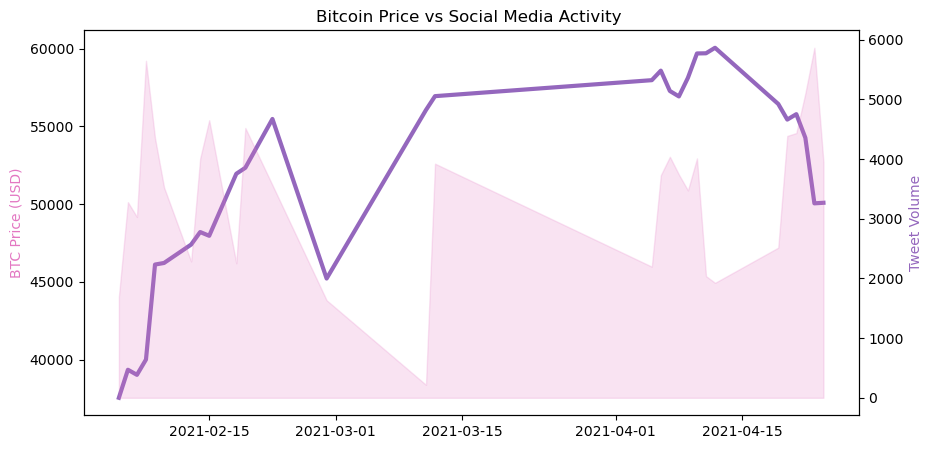

In [177]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
ax2.fill_between(final_daily_df['Date'], final_daily_df['Tweet Volume'], 
                 color="tab:pink", alpha=0.2, label='Tweet Volume')
ax2.set_ylabel('Tweet Volume', color="tab:purple")

ax1.plot(final_daily_df['Date'], final_daily_df['BTC Price'], 
         color="tab:purple", linewidth=3, label='BTC Price')
ax1.set_ylabel('BTC Price (USD)', color="tab:pink")

plt.title('Bitcoin Price vs Social Media Activity ', fontsize=12)
plt.show()

Тo back up the visual findings, I calculated the correlation coefficient between market price and social activity. This numerical value helps determine how strongly the two variables are related.

In [176]:
correlation = final_daily_df['BTC Price'].corr(final_daily_df['Tweet Volume'])

max_price = final_daily_df['BTC Price'].max()
max_tweets = final_daily_df['Tweet Volume'].max()

print(f"Correlation between Price and Tweets: {correlation:.2f}")
print(f"Highest Bitcoin Price in dataset: ${max_price:,.2f}")
print(f"Highest Tweet Volume in a single day: {max_tweets:,}")

Correlation between Price and Tweets: -0.07
Highest Bitcoin Price in dataset: $60,056.33
Highest Tweet Volume in a single day: 5,865


Instead of just counting the number of tweets, I decided to also analyze the "Social Reach" of the discussion. The logic is that a tweet from an account with millions of followers likely has a much higher impact on the market than hundreds of tweets from accounts with no followers. By calculating the total sum of followers for everyone tweeting on a given day, I created a "Weight of Influence" metric. This helps to distinguish between general "noise" and high-impact social momentum.

In [182]:
daily_influence = tweets_df.groupby('date').agg({
    'user_followers': 'sum'
}).reset_index()

final_daily_df = final_daily_df.merge(daily_influence, left_on='Date', right_on='date')

follower_corr = final_daily_df['BTC Price'].corr(final_daily_df['user_followers'])
print(f"Correlation between Total Followers Reach and Price: {follower_corr:.2f}")

Correlation between Total Followers Reach and Price: -0.26
